In [1]:
import pandas as pd
import os

path_to_data = '../data/messages.csv'

print(f"Файл найден по указанному пути: {os.path.exists(path_to_data)}")

df = pd.read_csv(path_to_data)

df.head()

Файл найден по указанному пути: True


,id,text
0,18789fab-71ae-4b8b-9a65-c653af3a1d94,Авария 10001\nИС: Keycloak IdP\nОписание: 1018...
1,7210f58d-88ba-491b-812b-9d4d150dcb65,Авария 10002\nИС: GitLab CI\nОписание: 3500\nН...
2,727d04ef-8e6c-437a-8685-69d25c0f0f97,Авария 10003\nИС: Deposits Back-Office\nОписан...
3,acdaea40-2637-4055-998d-026ad2f21148,Авария 10004\nИС: ElasticSearch\nОписание: 101...
4,a6b7f5c4-cf67-47da-b0e2-7c9c604d01b6,Авария 10005\nИС: Monitoring (Zabbix)\nОписани...


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45842 entries, 0 to 45841
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      45842 non-null  object
 1   text    45842 non-null  object
dtypes: object(2)
memory usage: 716.4+ KB


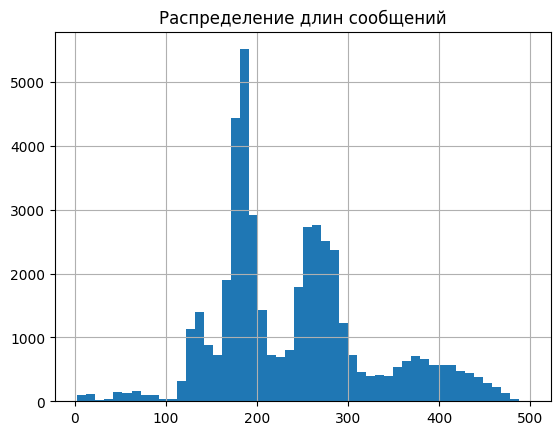

In [3]:
#анализ длин сообщений
import matplotlib.pyplot as plt

# Создаем новую колонку с длиной каждого сообщения
df['text_len'] = df['text'].astype(str).str.len() # Добавим .astype(str) на случай, если есть не-текстовые данные

# Строим гистограмму распределения длин
df['text_len'].hist(bins=50)
plt.title('Распределение длин сообщений')
plt.show()

In [4]:
#анализ самых частых слов
from collections import Counter

# Получаем все слова из всех сообщений в один большой список
# Убедимся, что все данные текстовые
all_words = ' '.join(df['text'].astype(str)).lower().split()

# Считаем частоту каждого слова
word_counts = Counter(all_words)

# Смотрим на 20 самых частых слов
word_counts.most_common(20)

[('на', 62745),
 ('описание:', 41379),
 ('dion:', 38435),
 ('ис:', 36933),
 ('-', 31619),
 ('авария:', 30406),
 ('группу:', 29932),
 ('назначено', 29930),
 ('в', 11042),
 ('по', 9997),
 ('тех.стек:', 8000),
 ('os:', 8000),
 ('авария', 7924),
 ('=', 7670),
 ('postgresql', 7362),
 ('ошибка', 7213),
 ('linux', 7212),
 ('сбой', 7178),
 ('ис', 6998),
 ('server', 6873)]

In [9]:
import pandas as pd
from pandarallel import pandarallel

# Загрузка ресурсов NLTK в основном процессе 
import nltk
print("Загружаю ресурсы NLTK...")
try:
    nltk.data.find('corpora/stopwords')
except nltk.downloader.DownloadError:
    nltk.download('stopwords')
print("Ресурсы NLTK готовы.")

def preprocess_text_final_parallel(text):
    # Каждый воркер выполнит этот блок и импортирует все, что ему нужно.
    import re
    from pymystem3 import Mystem
    from nltk.corpus import stopwords

    mystem = Mystem()
    russian_stopwords = set(stopwords.words("russian"))
    
    text = str(text).lower()
    text = re.sub(r'[^а-яА-ЯёЁ\s]', ' ', text)
    tokens = mystem.lemmatize(text)
    tokens = [token for token in tokens if token.strip() and token not in russian_stopwords]
    
    return " ".join(tokens)

# Инициализация pandarallel
pandarallel.initialize(progress_bar=True, verbose=2)

print("Запускаю параллельную обработку текстов. Это может занять некоторое время...")
df['processed_text'] = df['text'].parallel_apply(preprocess_text_final_parallel)
print("Обработка завершена!")

display(df[['text', 'processed_text']].head())

df.to_csv('../data/messages_processed.csv', index=False)
print("\nОбработанные данные сохранены в файл 'messages_processed.csv'")

Загружаю ресурсы NLTK...
Ресурсы NLTK готовы.
INFO: Pandarallel will run on 6 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.

https://nalepae.github.io/pandarallel/troubleshooting/
Запускаю параллельную обработку текстов. Это может занять некоторое время...


Обработка завершена!


,text,processed_text
0,Авария 10001\nИС: Keycloak IdP\nОписание: 1018...,авария иса описание назначать группа платежный...
1,Авария 10002\nИС: GitLab CI\nОписание: 3500\nН...,авария иса описание назначать группа операцион...
2,Авария 10003\nИС: Deposits Back-Office\nОписан...,авария иса описание недоступность авторизация ...
3,Авария 10004\nИС: ElasticSearch\nОписание: 101...,авария иса описание назначать группа
4,Авария 10005\nИС: Monitoring (Zabbix)\nОписани...,авария иса описание высокий загрузка узел назн...



Обработанные данные сохранены в файл 'messages_processed.csv'


In [10]:
# --- Тестирование функции предобработки ---

test_messages = [
    "Срочно! система не смогла обнаружить сервер!",
    "Внимание, наблюдается высокая загрузка CPU на узле monitoring-db-01.",
    "Плановые технические работы на системе GitLab CI с 22:00 до 23:00.",
    "Ошибка авторизации пользователя в ИС Keycloak IdP.",
    "Недоступность Deposits Back-Office, разбираемся.",
    "Завтра в 10 утра будет перезагрузка.",
    "Проблема с платежным шлюзом, транзакции не проходят."
]

print("--- Результаты тестирования функции очистки ---")
for message in test_messages:
    processed = preprocess_text_final_parallel(message) 
    print(f"Исходное:  {message}")
    print(f"Обработанное: {processed}\n")

--- Результаты тестирования функции очистки ---
Исходное:  Срочно! система не смогла обнаружить сервер!
Обработанное: срочно система смочь обнаруживать сервер

Исходное:  Внимание, наблюдается высокая загрузка CPU на узле monitoring-db-01.
Обработанное: внимание наблюдаться высокий загрузка узел

Исходное:  Плановые технические работы на системе GitLab CI с 22:00 до 23:00.
Обработанное: плановый технический работа система

Исходное:  Ошибка авторизации пользователя в ИС Keycloak IdP.
Обработанное: ошибка авторизация пользователь иса

Исходное:  Недоступность Deposits Back-Office, разбираемся.
Обработанное: недоступность разбираться

Исходное:  Завтра в 10 утра будет перезагрузка.
Обработанное: завтра утро перезагрузка

Исходное:  Проблема с платежным шлюзом, транзакции не проходят.
Обработанное: проблема платежный шлюз транзакция проходить



In [11]:
# --- Векторизация текстов ---

from sklearn.feature_extraction.text import TfidfVectorizer

print("Создаю векторизатор...")
# найдем до 5000 самых значимых слов/словосочетаний.
# ngram_range=(1, 2) - будет учитывать не только отдельные слова, но и пары слов (биграммы),
# что часто улучшает качество кластеризации (например, "плановые работы").
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

print("Преобразую тексты в матрицу TF-IDF...")
# используем df['processed_text'], в котором могут быть NaN после обработки.
# .fillna('') заменяет пустые значения на пустую строку, чтобы избежать ошибок.
X = vectorizer.fit_transform(df['processed_text'].fillna(''))

print("Векторизация завершена!")
print(f"Размер полученной матрицы: {X.shape}") # Покажет (количество_документов, количество_признаков)

Создаю векторизатор...
Преобразую тексты в матрицу TF-IDF...
Векторизация завершена!
Размер полученной матрицы: (45842, 5000)


In [12]:
# --- Кластеризация ---

from sklearn.cluster import KMeans

# количество паттернов, которые мы ожидаем найти. 
num_clusters = 30

print(f"Запускаю кластеризацию на {num_clusters} кластеров...")
# n_init='auto' - важное изменение для новых версий scikit-learn
kmeans = KMeans(n_clusters=num_clusters, n_init='auto', random_state=42)

# Обучаем модель и сразу добавляем метку кластера для каждого сообщения в наш DataFrame
df['cluster'] = kmeans.fit_predict(X)

print("Кластеризация завершена!")

# Смотрим, сколько сообщений попало в каждый кластер
print("\nРаспределение сообщений по кластерам:")
print(df['cluster'].value_counts())

Запускаю кластеризацию на 30 кластеров...
Кластеризация завершена!

Распределение сообщений по кластерам:
cluster
11    7962
0     3500
3     2485
5     2318
23    2230
8     2014
4     2000
17    1809
26    1696
14    1661
6     1625
13    1527
2     1495
10    1437
24    1296
9     1100
29    1065
7     1006
12    1000
18     993
28     866
1      824
22     712
15     672
21     577
19     574
16     443
25     360
27     353
20     242
Name: count, dtype: int64


In [14]:
# --- Анализ результатов кластеризации ---

for i in range(num_clusters):
    print(f"\n========== Примеры для Кластера {i} ==========")
    
    # Отбираем сообщения из текущего кластера
    cluster_df = df[df['cluster'] == i]
    
    # `replace=False` чтобы не было повторений, если в кластере мало сообщений
    # min(10, len(cluster_df)) - чтобы не было ошибки, если в кластере меньше 10 сообщений
    sample_size = min(10, len(cluster_df))
    if sample_size > 0:
        cluster_examples = cluster_df['text'].sample(sample_size, replace=False).tolist()
        for example in cluster_examples:
            # Выводим исходный, "грязный" текст для лучшего понимания
            clean_example = str(example).strip().replace('\n', ' ')
            print(f"- {clean_example}")
    else:
        print("В этом кластере нет сообщений.")


========== Примеры для Кластера 0 ==========
- Контур: ПРЕПРОД EM-12345  ИС: SMA Scheduler  Описание: Проблемы с файловой системой /data. core01.bank.lan монтирует раздел в read-only.  Куратор: Романов Кирилл Евгеньевич  DION: https://meet.bank.local/room/dwh Коллеги от ИС 480, просьба подключиться к аварийной конференции
- Контур: ИФТ EM-11989  ИС: SMA Scheduler  Описание: Недоступен порт 443 на veeam-proxy01.bank.lan. Ошибка TLS handshake.  Куратор: Смирнова Ольга Николаевна  DION: https://meet.bank.local/room/linux Коллеги от ИС 484, просьба подключиться к аварийной конференции
- Контур: ИФТ EM-10717  ИС: Kafka Bus  Описание: Отсутствует heartbeat от doc-prod01.intra.bank. Подозрение на сбой гипервизора.  Куратор: Волкова Анастасия Олеговна  DION: https://meet.bank.local/room/postgres Коллеги от ИС 660, просьба подключиться к аварийной конференции
- Контур: Хотфикс EM-20261  ИС: SMA Scheduler  Описание: Недоступен сервис авторизации. HTTP 500 при обращении к /auth на pg-cluster03.d

In [20]:
# --- Кластеризация на 27 кластеров(заявленное)---

from sklearn.cluster import KMeans

# количество паттернов, которые мы ожидаем найти. 
num_clusters = 27

print(f"Запускаю кластеризацию на {num_clusters} кластеров...")
# n_init='auto' - важное изменение для новых версий scikit-learn
kmeans = KMeans(n_clusters=num_clusters, n_init='auto', random_state=42)

# Обучаем модель и сразу добавляем метку кластера для каждого сообщения в наш DataFrame
df['cluster'] = kmeans.fit_predict(X)

print("Кластеризация завершена!")

# Смотрим, сколько сообщений попало в каждый кластер
print("\nРаспределение сообщений по кластерам:")
print(df['cluster'].value_counts())

Запускаю кластеризацию на 27 кластеров...
Кластеризация завершена!

Распределение сообщений по кластерам:
cluster
11    5292
17    5183
0     3500
3     2501
5     2324
23    2230
8     2014
4     2000
14    1876
18    1856
26    1696
6     1625
13    1527
2     1495
10    1444
7     1359
24    1297
9     1100
12    1000
1      827
22     712
15     672
21     577
19     574
16     559
25     360
20     242
Name: count, dtype: int64


In [21]:
# --- Анализ результатов заявленных кластеров ---

for i in range(num_clusters):
    print(f"\n========== Примеры для Кластера {i} ==========")
    
    # Отбираем сообщения из текущего кластера
    cluster_df = df[df['cluster'] == i]
    
    # `replace=False` чтобы не было повторений, если в кластере мало сообщений
    # min(10, len(cluster_df)) - чтобы не было ошибки, если в кластере меньше 10 сообщений
    sample_size = min(10, len(cluster_df))
    if sample_size > 0:
        cluster_examples = cluster_df['text'].sample(sample_size, replace=False).tolist()
        for example in cluster_examples:
            # Выводим исходный, "грязный" текст для лучшего понимания
            clean_example = str(example).strip().replace('\n', ' ')
            print(f"- {clean_example}")
    else:
        print("В этом кластере нет сообщений.")


========== Примеры для Кластера 0 ==========
- Контур: Хотфикс EM-20004  ИС: Nexus Repo  Описание: Отсутствует heartbeat от aml-node01.dc.local. Подозрение на сбой гипервизора.  Куратор: Алексеева Дарья Николаевна  DION: https://meet.bank.local/room/fraud Коллеги от ИС 63, просьба подключиться к аварийной конференции
- Контур: ПРЕПРОД EM-11014  ИС: Deposits Back-Office  Описание: Ошибка репликации PostgreSQL. Replica lag = 6309 сек. Хост: gitlab-ci01.corp.local.  Куратор: Николаев Иван Михайлович  DION: https://meet.bank.local/room/esb Коллеги от ИС 391, просьба подключиться к аварийной конференции
- Контур: ИФТ EM-12829  ИС: SAP FI  Описание: Недоступен сервис авторизации. HTTP 500 при обращении к /auth на dwh-etl01.dc.local.  Куратор: Григорьев Николай Владимирович  DION: https://meet.bank.local/room/linux Коллеги от ИС 929, просьба подключиться к аварийной конференции
- Контур: Хотфикс EM-20193  ИС: Backups (Veeam)  Описание: Недоступен сервис авторизации. HTTP 500 при обращении к 

In [23]:
# Финальная карта кластеров для n_clusters=27

cluster_map = {
    # "Чистые" кластеры
    3:  "Сетевая недоступность (TLS/HTTPS/Ping)",
    5:  "Проблемы с ФС (/pg_walarchive)",
    8:  "Сбой сервиса PostgreSQL",
    10: "Широкомасштабный сбой",
    13: "Ошибка репликации PostgreSQL",
    15: "Проблемы с Zabbix-агентом",
    18: "Сбой соединения с Oracle (ORA-12514)",
    20: "Ошибка записи на SMB-шару",
    21: "Проблемы с очередями / репликацией",
    22: "Проблемы с памятью (RAM/SWAP)",
    23: "Падение компонентов (Pods/Agents)",
    25: "Проблемы с местом на диске",
    26: "Отсутствие Heartbeat",
    
    # Объединяем дублирующиеся кластеры
    1:  "API Авторизации (HTTP 500)",
    24: "API Авторизации (HTTP 500)",

    6:  "Высокая загрузка CPU",
    14: "Высокая загрузка CPU",
    16: "Высокая загрузка CPU",
    
    # Кластеры, которые можно объединить в один "общий"
    7:  "Превышение порогов (Мониторинг)",
    16: "Превышение порогов (Мониторинг)",  #Кластер 16 очень похож и на CPU, и на пороги, отнесем его сюда

    # "Мусорные" и "шаблонные" кластеры помечаем как 'Прочее'
    0:  "Прочее", # Шаблон "Контур..."
    2:  "Прочее", # Шаблон "Сервис..."
    4:  "Прочее", # Шаблон "Тех.стек"
    9:  "Прочее", # Шаблон "ФинБанк"
    11: "Прочее", # Разный мусор
    12: "Прочее", # Шаблон "Зарегистрирован инцидент"
    17: "Прочее", # Короткие сообщения
    19: "Прочее", # Еще один "Тех.стек"
}


In [24]:
# Применяем нашу карту к колонке 'cluster', чтобы создать новую колонку 'pattern_name'
# .map() заменяет каждое значение в колонке согласно словарю.
# .fillna('Прочее') - все кластеры, которых не было в нашем словаре, автоматически станут 'Прочее'.
df['pattern_name'] = df['cluster'].map(cluster_map).fillna('Прочее')

print("Новая колонка 'pattern_name' создана. Результат:")

# Выведем количество сообщений для каждого нового паттерна
print("\nРаспределение сообщений по новым паттернам:")
print(df['pattern_name'].value_counts())

Новая колонка 'pattern_name' создана. Результат:

Распределение сообщений по новым паттернам:
pattern_name
Прочее                                    20144
Высокая загрузка CPU                       3501
Сетевая недоступность (TLS/HTTPS/Ping)     2501
Проблемы с ФС (/pg_walarchive)             2324
Падение компонентов (Pods/Agents)          2230
API Авторизации (HTTP 500)                 2124
Сбой сервиса PostgreSQL                    2014
Превышение порогов (Мониторинг)            1918
Сбой соединения с Oracle (ORA-12514)       1856
Отсутствие Heartbeat                       1696
Ошибка репликации PostgreSQL               1527
Широкомасштабный сбой                      1444
Проблемы с памятью (RAM/SWAP)               712
Проблемы с Zabbix-агентом                   672
Проблемы с очередями / репликацией          577
Проблемы с местом на диске                  360
Ошибка записи на SMB-шару                   242
Name: count, dtype: int64


In [26]:
# Создаем новый DataFrame, в котором будут ТОЛЬКО сообщения с определенными паттернами
# Мы отфильтровываем все строки, где 'pattern_name' равен 'Прочее'
labeled_df = df[df['pattern_name'] != 'Прочее'].copy()

# Нам больше не нужны промежуточные результаты, оставим только самое важное
final_df = labeled_df[['text', 'processed_text', 'pattern_name']]

print(f"Исходное количество сообщений: {len(df)}")
print(f"Количество сообщений после удаления 'Прочего': {len(final_df)}")
print("\nПримеры из финального размеченного датасета:")
display(final_df.sample(10)) # Посмотрим на 10 случайных строк из нашего чистого набора

# Сохраняем этот "чистый" датасет в новый файл.
final_df.to_csv('../data/final_labeled_dataset.csv', index=False)

print("\nФинальный размеченный датасет сохранен в файл 'final_labeled_dataset.csv'")

Исходное количество сообщений: 45842
Количество сообщений после удаления 'Прочего': 25698

Примеры из финального размеченного датасета:


,text,processed_text,pattern_name
20489,Авария: EM-12390 \nИС: Payment Hub \nОписание:...,авария иса описание отсутствовать подозрение с...,Отсутствие Heartbeat
29190,Авария: [EM-71791] (https://servicedesk.ru/EM-...,авария иса описание учебный авария сервис сост...,Сбой сервиса PostgreSQL
33335,Авария EM-92436 - Падение pod'ов Kubernetes в ...,авария падение ов перезапускаться иса описание...,Падение компонентов (Pods/Agents)
28457,Авария: [EM-71058] (https://servicedesk.ru/EM-...,авария иса описание учебный авария отсутствова...,Отсутствие Heartbeat
28445,Авария: [EM-71046] (https://servicedesk.ru/EM-...,авария иса описание учебный авария ошибка авто...,Высокая загрузка CPU
40555,https://servicedesk.ru/EM-60257\nИС: Card Proc...,иса описание критический заполнение файловый с...,Проблемы с ФС (/pg_walarchive)
18731,Авария: EM-10632 \nИС: Backups (Veeam) \nОписа...,авария иса описание сервис состояние репликаци...,Сбой сервиса PostgreSQL
27497,Авария: [EM-70098] (https://servicedesk.ru/EM-...,авария иса описание учебный авария ошибка авто...,Высокая загрузка CPU
33862,Подозрение на широкомасштабный сбой по КЕ: Bac...,подозрение широкомасштабный сбой ке авария мин...,Широкомасштабный сбой
28683,Авария: [EM-71284] (https://servicedesk.ru/EM-...,авария иса описание учебный авария падение ов ...,Падение компонентов (Pods/Agents)



Финальный размеченный датасет сохранен в файл 'final_labeled_dataset.csv'
